Dieser Code trainiert und evaluiert ein BERT-Modell anhand dieses Datensatzes:

@inproceedings{tonneau-etal-2024-languages,

    title = "From Languages to Geographies: Towards Evaluating Cultural Bias in Hate Speech Datasets",

    author = {Tonneau, Manuel  and
      Liu, Diyi  and
      Fraiberger, Samuel  and
      Schroeder, Ralph  and
      Hale, Scott  and
      Röttger, Paul},
    editor = {Chung, Yi-Ling  and
      Talat, Zeerak  and
      Nozza, Debora  and
      Plaza-del-Arco, Flor Miriam  and
      Röttger, Paul  and
      Mostafazadeh Davani, Aida  and
      Calabrese, Agostina},
    
    booktitle = "Proceedings of the 8th Workshop on Online Abuse and Harms (WOAH 2024)",
    month = jun,
    year = "2024",
    address = "Mexico City, Mexico",
    publisher = "Association for Computational Linguistics",
    url = "https://aclanthology.org/2024.woah-1.23",
    pages = "283--311",
    abstract = "Perceptions of hate can vary greatly across cultural contexts.
    Hate speech (HS) datasets, however, have traditionally been developed by
    language. This hides potential cultural biases, as one language may be
    spoken in different countries home to different cultures. In this work, we
    evaluate cultural bias in HS datasets by leveraging two interrelated
    cultural proxies: language and geography. We conduct a systematic survey
    of HS datasets in eight languages and confirm past findings on their
    English-language bias, but also show that this bias has been steadily
    decreasing in the past few years. For three geographically-widespread
    languages{---}English, Arabic and Spanish{---}we then leverage
    geographical metadata from tweets to approximate geo-cultural contexts by
    pairing language and country information. We find that HS datasets for
    these languages exhibit a strong geo-cultural bias, largely
    overrepresenting a handful of countries (e.g., US and UK for English)
    relative to their prominence in both the broader social media population
    and the general population speaking these languages. Based on these
    findings, we formulate recommendations for the creation of future HS
    datasets.",}


In [ ]:
!pip install transformers==5.16.1


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn
import sklearn.metrics as metrics

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import torch
from torch.utils.data import Dataset

import transformers

from transformers import (
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding
)

print(transformers.__version__)
print(transformers.__file__)

5.16.1
/usr/local/lib/python3.13/dist-packages/transformers/__init__.py


In [ ]:
#nötig um auf google colab auf die daten zugriff zuhaben

#from google.colab import drive
#drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
df = pd.read_csv(
    #"/content/drive/MyDrive/Colab Notebooks/de_hf_112024.csv",sep=",",engine="python",on_bad_lines="skip",encoding="utf-8")
    "de_hf_112024.csv",sep=",",engine="python",on_bad_lines="skip",encoding="utf-8")
df.head()


,text,labels,source,dataset,nb_annotators
0,gleich an die wand stellen und erschiessen..,1.0,Facebook,Bretschneider,2.0
1,nicht dass ich der Grundbotschaft dieses Post'...,0.0,Facebook,Bretschneider,2.0
2,"Das mit dem ""an die Wand stellen und erschiessen""",0.0,Facebook,Bretschneider,2.0
3,"Seit dem ""an die Wand stellen und erschiessen""...",0.0,Facebook,Bretschneider,2.0
4,Ja ja die Kriminelle Heimatpartei FPÖ von Kind...,0.0,Facebook,Bretschneider,2.0


In [ ]:
#löscht die zeilen die nan werte in der spalte labels haben
df=df.dropna(subset=["labels"])

In [ ]:
from sklearn.model_selection import train_test_split
#dataframe wird nur mit text und labels als integer definiert
X=df["text"]
y=df["labels"].astype(int)

datensatz wird in train-,test-, validierungsdatensatz aufgeteilt

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size=0.1,random_state=42,stratify=y_train)

der index wird noch mal neu gesetzt da er jetzt durch den random-state durcheinander gekommen ist

In [ ]:
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

X_val = X_val.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)

X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [ ]:
#Tokenizer für das deutsche bert Laden
model_standard="bert-base-german-cased"
tokenizer=AutoTokenizer.from_pretrained(model_standard)

config.json:   0%|          | 0.00/433 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/255k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/485k [00:00<?, ?B/s]

der tokenizer wird auf die datensätze angewendet, truncation=true erlaubt die texte abzuschneiden damit das BERT modell den kommentar annimmt

In [ ]:
train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
)

val_encodings = tokenizer(
    X_val.tolist(),
    truncation=True
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True
)

In [ ]:
class HateSpeechDataset(Dataset):

    def __init__(self, encodings, labels): #konstruktor, speicherung der tokenisierten TExte und des labels
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx): #einzelnes item gespeichert und zurückgegeben
        item = { #holt die tokens
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor( #fügt das label hinzu
            self.labels.iloc[idx],
            dtype=torch.long
        )

        return item

    def __len__(self):
        return len(self.labels)#gibt die länge des datensatzes, also die anzahl der labels zurück

#Datensätze werden erzeugt
train_dataset = HateSpeechDataset(train_encodings, y_train)
val_dataset = HateSpeechDataset(val_encodings, y_val)
test_dataset= HateSpeechDataset(test_encodings, y_test)

In [ ]:
#modell laden ist schon trainiert
model = AutoModelForSequenceClassification.from_pretrained( 
    model_standard,
    num_labels=2 #klassenanzahl
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  439MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-german-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
data_collator = DataCollatorWithPadding( #alle texte in einem batch haben die gleiche länge, den längsten text, damit sie in das modell passen
    tokenizer=tokenizer
)

Die class weights werden "balanced" ausgerechnet, damit wird automatisch die minderheitsklasse stärker berechnet.  unique bestimmt die klassen anhand der y-Spalte (labels) des traindatensatzes, dies ist wichtig da sie die Überprüfung der Klassifizierung ist. Die Ergebnisse könnte leicht abweichen da, die zufällige Initialisierung einiger GEwichte, das zufällige Shuffeln der Trainingsdaten sowie das Dropout während des Trainings das Training beeinflussen kann.

In [ ]:
class_weights=compute_class_weight(
    class_weight="balanced", #berechnet automatisch die 
    classes=np.unique(y_train),
    y=y_train
)
class_weights=torch.tensor(class_weights,dtype=torch.float) #nun werden die in PyTorchTensoren umgewandelt werden
class_weights = class_weights.to(model.device) #schiebt es auf die GPU

In [ ]:
#from transformers import TrainingArguments

#Trainingsparameter
training_args = TrainingArguments(
    eval_strategy="epoch", #nahc jeder epoche wird auf dem validierungsdatensatz validiert
    save_strategy="epoch", #nach jeder epoche wird das modell als checkpoint gespeichert
    load_best_model_at_end=True, #das beste modell wird gepseichert
    learning_rate=2e-5, #die größe des schrittes, der beim anpassen der gewichte gemacht wird
    per_device_train_batch_size=8, #8 kommentare werden gleichzeitig geladen und verarbeitet
    per_device_eval_batch_size=8, #8 kommentare werden gleichzeitig geladen und validiert
    gradient_accumulation_steps=2, #gaukelt dem GErät eine größere Batchgröße vor (verschnellert da training des modells, da fehlende vorgegebene Sequenzlänge)
    #aktualisiert nur jedes zweite batch die gewichte
    num_train_epochs=5, #maximale epochenanzahl
    weight_decay=0.01, #gewichtungsabnahme, um overfitting zu vermeiden
    logging_steps=50, #alle 50 trainingsschritte werden verluste und genauigkeit gespeichert
    fp16=True# Mixed Precision Training berechnungen werden mit dem 16 gleitkommabit gemacht 
)


In [ ]:
#Trainer von Hugging Face
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)], #early stopping nach 2 epochen ohne verbesserung
    compute_loss_func=lambda outputs,labels,num_items_in_batch=None:torch.nn.CrossEntropyLoss(weight=class_weights)(outputs.logits, labels) 
    #Berechnet den loss anhand der logits und der echten labels, fehler der minderheitsklasse werden durch class_weights stärker gewichtet
)
#Modell Training starten --> Fine Tuning
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.782208,0.363292
2,0.907951,0.441204
3,0.350394,1.014180


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=6825, training_loss=0.6509145378979134, metrics={'train_runtime': 1004.5418, 'train_samples_per_second': 181.127, 'train_steps_per_second': 11.324, 'total_flos': 5206659452306400.0, 'train_loss': 0.6509145378979134, 'epoch': 3.0})

der trainer von Hugging-Face lässt das modell auf dem testadtensatz laufen und rechnet mit predict() die Logitsmatrixen aus. 
der torch.softmax wandelt die logits in wahrscheinlichkeitmatrixen um.anschließend wird mit [:,1] nur die label 1 spalte genommen und die mit der Standardschwelle 0,5 vergleichen und mit astype(int) in 0 und 1 als "richtiges" label gespeichert in y_val_pred. 

In [ ]:
pred_output = trainer.predict(val_dataset)
y_val_proba = torch.softmax(torch.tensor(pred_output.predictions), dim=1)[:,1].numpy()
y_valpred = (y_val_proba > 0.5).astype(int)

die gerechneten wahrscheinlichkeiten werdne in der datei gespeichert mit dem text und dem label, anschließend wird die optimale schwelle berechnet und anhand des f1-scores bewertet

In [ ]:
with open("bert_Classs_weights.txt", "w") as fd:
    for text, label, proba in zip(X_val, y_val, y_val_proba):
        fd.write(f"Text: {text}\n")
        fd.write(f"Label: {label}\n")
        fd.write(f"Wahrscheinlichkeit Hasskommentar: {proba}\n")
        fd.write("\n"*4)
schwellen = np.arange(0.0, 1.01, 0.01) #schwelle von 0.0 bis 1.01 in 0.01 Schritten
beste_schwelle = 0
beste_f1 = 0

for t in schwellen:
    y_pred_t = (y_val_proba > t).astype(int) #schwelle auf die wahrscheinlichkeiten anwenden
    f1 = metrics.f1_score(y_val, y_pred_t) #F1-score berechnen
    if f1 > beste_f1: #wenn der f1-score besser ist als der bisher beste, dann wird
        beste_f1 = f1 #f1 als bester_f1 speichern
        beste_schwelle = t #t als beste_schwelle speichern
        print("Schwelle: ", beste_schwelle)
        print("F1_score: ", beste_f1)
        print("\n"*4)

print("Beste Schwelle:", beste_schwelle)
print("Bester F1-Score:", beste_f1)

Schwelle:  0.0
F1_score:  0.22163588390501318





Schwelle:  0.01
F1_score:  0.31023720349563044





Schwelle:  0.02
F1_score:  0.3672106824925816





Schwelle:  0.03
F1_score:  0.3986954749286588





Schwelle:  0.04
F1_score:  0.4217391304347826





Schwelle:  0.05
F1_score:  0.4409881061299177





Schwelle:  0.06
F1_score:  0.4547607768829938





Schwelle:  0.07
F1_score:  0.466796875





Schwelle:  0.08
F1_score:  0.4795969773299748





Schwelle:  0.09
F1_score:  0.4896907216494845





Schwelle:  0.1
F1_score:  0.5





Schwelle:  0.11
F1_score:  0.5067677314564158





Schwelle:  0.12
F1_score:  0.5146005509641873





Schwelle:  0.13
F1_score:  0.5213004484304933





Schwelle:  0.14
F1_score:  0.5269186712485682





Schwelle:  0.15
F1_score:  0.5303030303030303





Schwelle:  0.16
F1_score:  0.5367298578199052





Schwelle:  0.17
F1_score:  0.542942942942943





Schwelle:  0.18
F1_score:  0.5473300970873787





Schwelle:  0.19
F1_score:  0.5543945912722803





Sch

Die Confusion Matrix wird mithilfe von matplotlib (plt) angezeigt und mit den sklearn metrics ausgerechnet. Die Seaborn-Heatmap ist die eigentliche Darstellung. Die CM wird mit ganzen Zahlen (fmt="d") in einem Blauen Farbschema (cmap="Blues") angezeigt

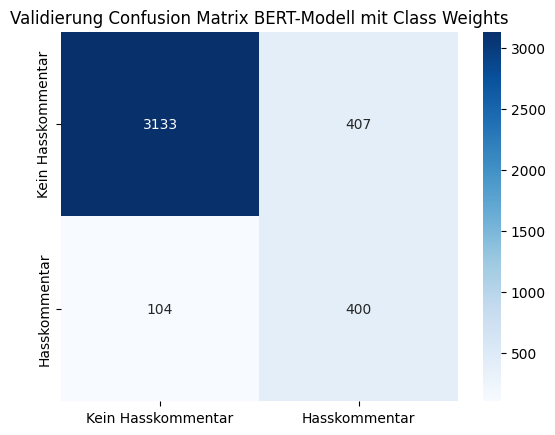

In [ ]:
cm = metrics.confusion_matrix(y_val, y_valpred)
sns.heatmap(
    cm,
    annot=True, #zeigt werte an, annotation
    fmt="d", # integer gibt ganze zahl an, sonst mit nachkommastellen
    cmap="Blues",# farbpalette, helle farbe = kleiner wert / dunkle farbe = hoher wert
    xticklabels=["Kein Hasskommentar","Hasskommentar"], #beschriftung der x achse
    yticklabels=["Kein Hasskommentar","Hasskommentar"] #beschriftung y achse
)
plt.title("Validierung Confusion Matrix BERT-Modell mit Class Weights")
plt.show()

In [ ]:
#metriken berechnen
# accuracy
vaccuracy = metrics.accuracy_score(y_val, y_valpred)
# precision
vprecision = metrics.precision_score(y_val, y_valpred)
# recall
vrecall = metrics.recall_score(y_val, y_valpred)
# f1-score
vf1=metrics.f1_score(y_val, y_valpred)
# specificity
tn, fp, fn, tp = metrics.confusion_matrix(y_val, y_valpred).ravel() #specificity muss manuell gerechnet werden da sklearn nicht die funktion hat
vspecificity = tn/(tn+fp)
# macro recall
vmacro_recall=metrics.recall_score(y_val, y_valpred, average='macro')
# macro f1-score
vmacro_f1=metrics.f1_score(y_val, y_valpred, average='macro')

In [ ]:
print("Accuracy: ", vaccuracy)
print("Precision: ", vprecision)
print("Recall: ", vrecall)
print("Specificity: ", vspecificity)
print("F1-Score: ", vf1)
print("Macro Recall: ", vmacro_recall)
print("Macro F1-Score: ", vmacro_f1)

Accuracy:  0.8810583580613254
Precision:  0.5153538050734312
Recall:  0.7658730158730159
Specificity:  0.8974576271186441
F1-Score:  0.6161213088587391
Macro Recall:  0.8316653214958301
Macro F1-Score:  0.7728741145610447


In [ ]:
trainer.save_model(
    "/content/drive/MyDrive/Colab Notebooks/BERT_model_Class_Weights"
)# das Modell mit seinen konfigurationen wird gespeichert, damit es später wieder geladen werden kann um Vorhersagen zu treffen.

tokenizer.save_pretrained(
    "/content/drive/MyDrive/Colab Notebooks/BERT_model_Class_Weights"
)#der tokenizer wird ebenfalls gespeichert, damit er später wieder geladen werden kann um den Datensatz richtig numerisch zu kodieren.

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/Colab Notebooks/BERT_model_Class_Weights/tokenizer_config.json',
 '/content/drive/MyDrive/Colab Notebooks/BERT_model_Class_Weights/tokenizer.json')

der trainer von Hugging-Face lässt das modell auf dem testadtensatz laufen und rechnet mit predict() die Logitsmatrixen aus. 
der torch.softmax wandelt die logits in wahrscheinlichkeitmatrixen um.anschließend wird mit [:,1] nur die label 1 spalte genommen und die mit der Standardschwelle 0,5 vergleichen und mit astype(int) in 0 und 1 als "richtiges" label gespeichert in y_pred. 

In [ ]:
pred_output = trainer.predict(test_dataset)
y_test_proba = torch.softmax(torch.tensor(pred_output.predictions), dim=1)[:,1].numpy()
y_pred = (y_test_proba > 0.5).astype(int)

Die Confusion Matrix wird mithilfe von matplotlib (plt) angezeigt und mit den sklearn metrics ausgerechnet. Die Seaborn-Heatmap ist die eigentliche Darstellung. Die CM wird mit ganzen Zahlen (fmt="d") in einem Blauen Farbschema (cmap="Blues") angezeigt

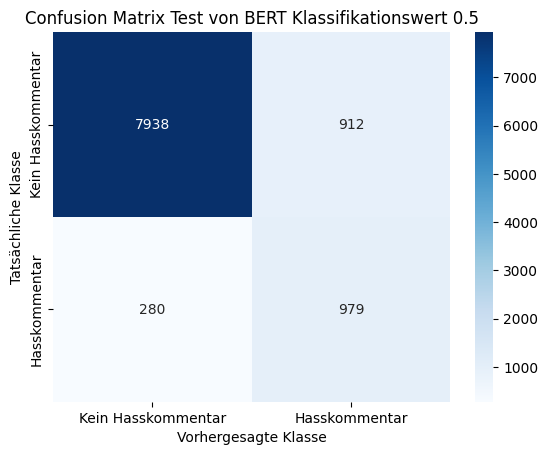

In [ ]:
# Confusion Matrix
cm = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True, #zeigt werte an, annotation
    fmt="d", # integer gibt ganze zahl an, sonst mit nachkommastellen
    cmap="Blues",# farbpalette, helle farbe = kleiner wert / dunkle farbe = hoher wert
    xticklabels=["Kein Hasskommentar","Hasskommentar"], #beschriftung der x achse
    yticklabels=["Kein Hasskommentar","Hasskommentar"] #beschriftung y achse
)
plt.title("Confusion Matrix Test von BERT Klassifikationswert 0.5")
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Tatsächliche Klasse")
plt.show()

In [ ]:
# accuracy
accuracy = metrics.accuracy_score(y_test, y_pred)
# precision
precision = metrics.precision_score(y_test, y_pred)
# recall
recall = metrics.recall_score(y_test, y_pred)
# f1-score
f1=metrics.f1_score(y_test, y_pred)
# specificity
tn, fp, fn, tp = metrics.confusion_matrix(y_test, y_pred).ravel() #specificity muss manuell gerechnet werden da sklearn keine funktion hat
specificity = tn/(tn+fp)
# macro recall
macro_recall=metrics.recall_score(y_test, y_pred, average='macro')
# macro f1-score
macro_f1=metrics.f1_score(y_test, y_pred, average='macro')

In [ ]:
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("Specificity: ", specificity)
print("F1-Score: ", f1)
print("Macro Recall: ", macro_recall)
print("Macro F1-Score: ", macro_f1)

Accuracy:  0.8820852705509942
Precision:  0.5177154944473823
Recall:  0.7776012708498808
Specificity:  0.8969491525423728
F1-Score:  0.6215873015873016
Macro Recall:  0.8372752116961268
Macro F1-Score:  0.7758745038520056


der trainer von Hugging-Face lässt das modell auf dem testadtensatz laufen und rechnet mit predict() die Logitsmatrixen aus. 
der torch.softmax wandelt die logits in wahrscheinlichkeitmatrixen um.anschließend wird mit [:,1] nur die label 1 spalte genommen und die mit der Standardschwelle 0,5 vergleichen und mit astype(int) in 0 und 1 als "richtiges" label gespeichert in y_pred. 
Anschließend werden die Wahrscheinlichkeiten mit der besten schwelle gespeichert

In [ ]:
pred_output = trainer.predict(test_dataset)
y_test_proba = torch.softmax(torch.tensor(pred_output.predictions), dim=1)[:,1].numpy()
y_pred = (y_test_proba > beste_schwelle).astype(int)

Die Confusion Matrix wird mithilfe von matplotlib (plt) angezeigt und mit den sklearn metrics ausgerechnet. Die Seaborn-Heatmap ist die eigentliche Darstellung. Die CM wird mit ganzen Zahlen (fmt="d") in einem Blauen Farbschema (cmap="Blues") angezeigt

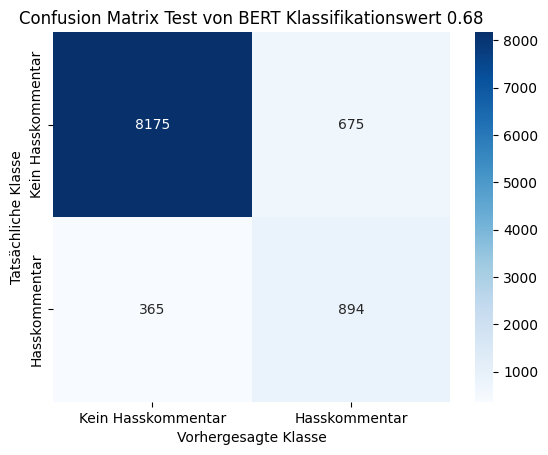

In [ ]:
# Confusion Matrix
cm = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True, #zeigt werte an, annotation
    fmt="d", # integer gibt ganze zahl an, sonst mit nachkommastellen
    cmap="Blues",# farbpalette, helle farbe = kleiner wert / dunkle farbe = hoher wert
    xticklabels=["Kein Hasskommentar","Hasskommentar"], #beschriftung der x achse
    yticklabels=["Kein Hasskommentar","Hasskommentar"] #beschriftung y achse
)
plt.title(f"Confusion Matrix Test von BERT Klassifikationswert {beste_schwelle}")
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Tatsächliche Klasse")
plt.show()

In [ ]:
# accuracy
accuracy = metrics.accuracy_score(y_test, y_pred)
# precision
precision = metrics.precision_score(y_test, y_pred)
# recall
recall = metrics.recall_score(y_test, y_pred)
# f1-score
f1=metrics.f1_score(y_test, y_pred)
# specificity
tn, fp, fn, tp = metrics.confusion_matrix(y_test, y_pred).ravel() #specificity muss manuell gerechnet werden, da sklearn keine funktion hat
specificity = tn/(tn+fp)
# macro recall
macro_recall=metrics.recall_score(y_test, y_pred, average='macro')
# macro f1-score
macro_f1=metrics.f1_score(y_test, y_pred, average='macro')

In [ ]:
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("Specificity: ", specificity)
print("F1-Score: ", f1)
print("Macro Recall: ", macro_recall)
print("Macro F1-Score: ", macro_f1)

Accuracy:  0.8971213769908003
Precision:  0.5697896749521989
Recall:  0.710087370929309
Specificity:  0.923728813559322
F1-Score:  0.6322489391796322
Macro Recall:  0.8169080922443155
Macro F1-Score:  0.7862222269216159
